STOCK TREND ANALYSIS WITH PYTHON

This notebook analyzes the perfomance of stock market. And answer the following questions:

What is the overall price trend of the selected stock over the past 5 years?
How do the 50-day and 200-day moving averages compare, and what do they indicate?
What were the highest and lowest volatility periods, and what caused them?
Are there any significant support/resistance levels in the stock’s price history

IMPORT IMPORTANT LIBRARIES

In [1]:
#IMPORT LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Download stock market data from yfinance

In [2]:
start_date = '2020-03-01'
end_date = '2025-03-31'

tickers = ("AAPL")
data = yf.download(tickers, start=start_date, end=end_date)
data = data.reset_index()

[*********************100%***********************]  1 of 1 completed


In [3]:
print(data.columns)

MultiIndex([(  'Date',     ''),
            ( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])


In [4]:
data.head(5)

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2020-03-02,72.071617,72.705962,66.984806,68.084656,341397200
1,2020-03-03,69.782692,73.323441,68.933679,73.243849,319475600
2,2020-03-04,73.019508,73.178698,70.701624,71.499980,219178400
3,2020-03-05,70.650978,72.250098,70.286771,71.278080,187572800
4,2020-03-06,69.712730,70.144472,67.831409,68.017126,226176800


In [5]:
#overview of dowmloaded data
data.describe()

Ticker,Date,AAPL
count,1277,1277.000000
mean,2022-09-11 15:06:37.494126848,158.254363
min,2020-03-02 00:00:00,54.449890
25%,2021-06-07 00:00:00,130.710236
50%,2022-09-12 00:00:00,155.828491
75%,2023-12-18 00:00:00,183.150391
max,2025-03-28 00:00:00,258.735504
std,NaN,42.658188


In [5]:
data.isnull()

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
1272,False,False,False,False,False,False
1273,False,False,False,False,False,False
1274,False,False,False,False,False,False


In [6]:
#50 and 200 days moving averages
data['MA50'] = data['Close'].rolling(window=50).mean()
data["MA200"] = data['Close'].rolling(window=200).mean()


#Calculate Bollinger band, to check for volatility

In [7]:
data['MA20'] = data['Close'].rolling(window=20).mean()
data['STD20'] = data['Close'].rolling(window=20).std()
data['Upper_Band'] = data['MA20'] + (2 * data['STD20'])
data['Lower_Band'] = data['MA20'] - (2 * data['STD20'])

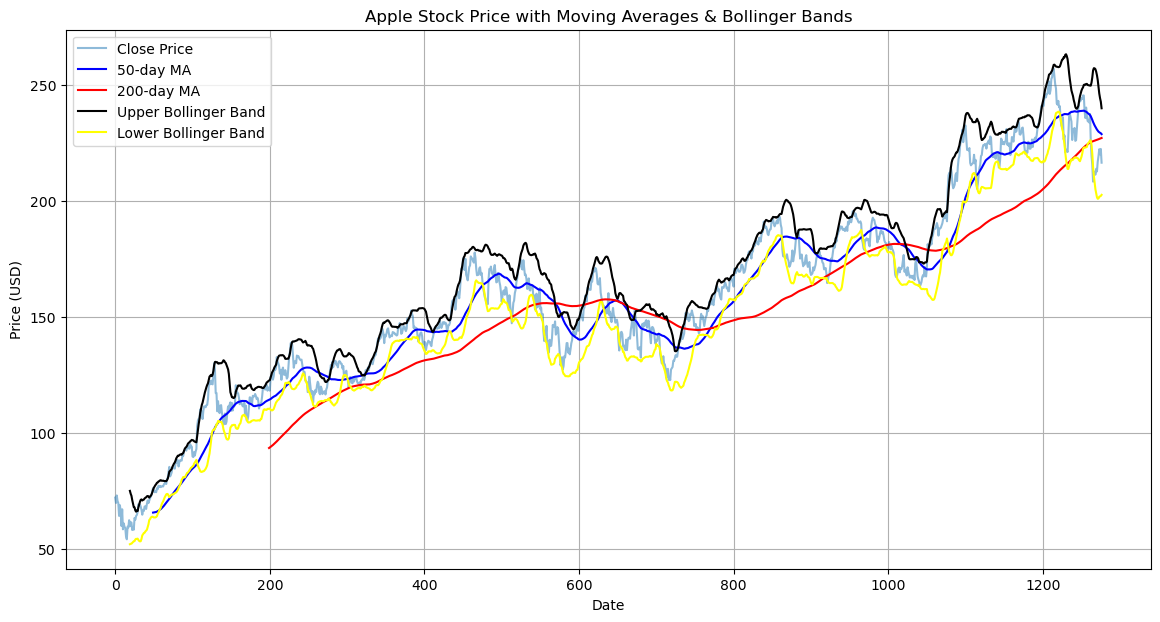

In [8]:
#Plot Closing Price with Moving Averages and Bollinger Bands

plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price', alpha=0.5)
plt.plot(data['MA50'], label='50-day MA', color='blue')
plt.plot(data['MA200'], label='200-day MA', color='red')
plt.plot(data['Upper_Band'], label='Upper Bollinger Band',  color='black')
plt.plot(data['Lower_Band'], label='Lower Bollinger Band',  color='yellow')
plt.title("Apple Stock Price with Moving Averages & Bollinger Bands")
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

Short-term moving averages crossing above long-term ones signaled strong buying opportunities in Apple Stock

In [33]:
data.head(3)

Price,Date,Close,High,Low,Open,Volume,MA50,MA200,MA20,STD20,Upper_Band,Lower_Band
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,
0,2020-03-02,72.514923,73.153170,67.396823,68.503439,341397200,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-03-03,70.211899,73.774425,69.357664,73.694344,319475600,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-03-04,73.468651,73.628820,71.136509,71.939776,219178400,NaN,NaN,NaN,NaN,NaN,NaN


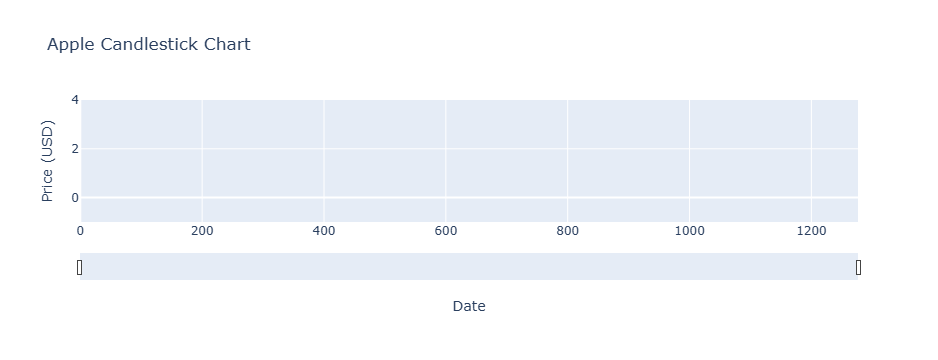

In [34]:
#Candlestick Chart with Volume
fig = go.Figure(data=[go.Candlestick(x=data.index,
                                     open=data['Open'],
                                     high=data['High'],
                                     low=data['Low'],
                                     close=data['Close'])])
fig.update_layout(title='Apple Candlestick Chart',
                  xaxis_title='Date',
                  yaxis_title='Price (USD)')
fig.show()

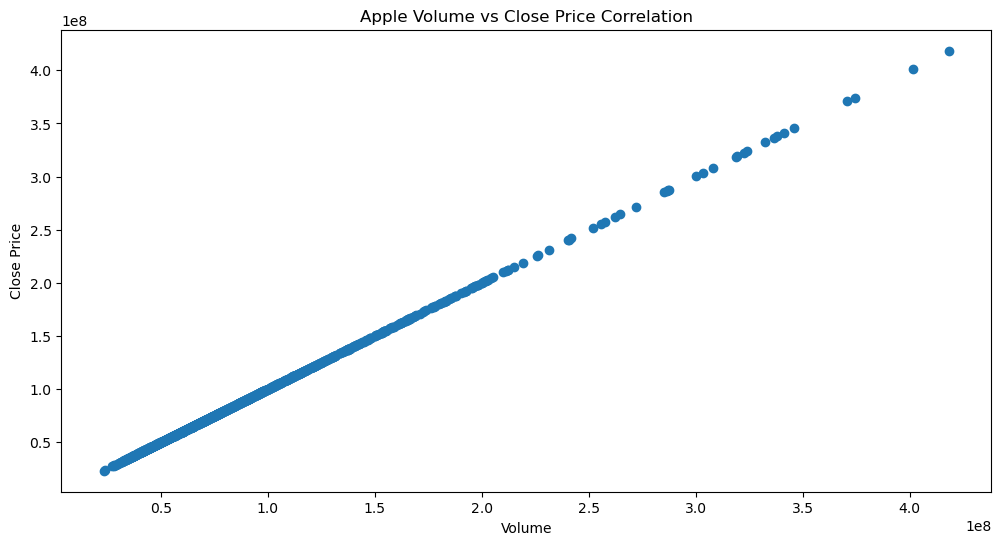

In [9]:
#Volume vs Price Correlation
#sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
plt.scatter(data['Volume'], (data['Volume']))
plt.title("Apple Volume vs Close Price Correlation")
plt.xlabel('Volume')
plt.ylabel('Close Price')
plt.show()


 positive correlation: increase in volume brings increase in price apple stock
 Short-term moving averages crossing above long-term ones signaled strong buying opportunities in Apple Stock

In [11]:
#Volatility analysis
data['Daily_Return'] = data['Close'].pct_change() 
volatility = data['Daily_Return'].rolling(window=30).std() * 100

data['Volatility'] = volatility
high_vol = data['Volatility'].nlargest(5)
print("Highest Volatility Periods:\n", data.loc[high_vol.index][['Volatility']])

Highest Volatility Periods:
 Price  Volatility
Ticker           
30       5.717597
31       5.688767
32       5.625970
34       5.607197
33       5.599263


TESLA STOCK ANALYSIS

In [12]:
start_date = '2020-03-01'
end_date = '2025-03-31'

tickers = ("TSLA")
data_tsla = yf.download(tickers, start=start_date, end=end_date)
data_tsla = data.reset_index()

[*********************100%***********************]  1 of 1 completed


In [48]:
data_tsla.head(5)

Price,index,Date,Close,High,Low,Open,Volume
Ticker,,,TSLA,TSLA,TSLA,TSLA,TSLA
0,0,2020-03-02,49.574669,49.579334,45.778000,47.417332,302925000
1,1,2020-03-03,49.700668,53.798668,47.740665,53.666668,386760000
2,2,2020-03-04,49.966667,51.101334,48.315334,50.930668,225735000
3,3,2020-03-05,48.302666,49.716667,47.871334,48.251331,162790500
4,4,2020-03-06,46.898666,47.133331,45.618000,46.000000,189943500


In [13]:
data_tsla.isnull()

Price,index,Date,Close,High,Low,Open,Volume,MA50,MA200,MA20,STD20,Upper_Band,Lower_Band,Daily_Return,Volatility
Ticker,,,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,,,,
0,False,False,False,False,False,False,False,True,True,True,True,True,True,True,True
1,False,False,False,False,False,False,False,True,True,True,True,True,True,False,True
2,False,False,False,False,False,False,False,True,True,True,True,True,True,False,True
3,False,False,False,False,False,False,False,True,True,True,True,True,True,False,True
4,False,False,False,False,False,False,False,True,True,True,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1273,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1274,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [14]:
#50 and 200 days moving averages
data_tsla['MA50'] = data_tsla['Close'].rolling(window=50).mean()
data_tsla["MA200"] = data_tsla['Close'].rolling(window=200).mean()
data_tsla['MA20'] = data_tsla['Close'].rolling(window=20).mean()
data_tsla['STD20'] = data_tsla['Close'].rolling(window=20).std()
data_tsla['Upper_Band'] = data_tsla['MA20'] + (2 * data_tsla['STD20'])
data_tsla['Lower_Band'] = data_tsla['MA20'] - (2 * data_tsla['STD20'])

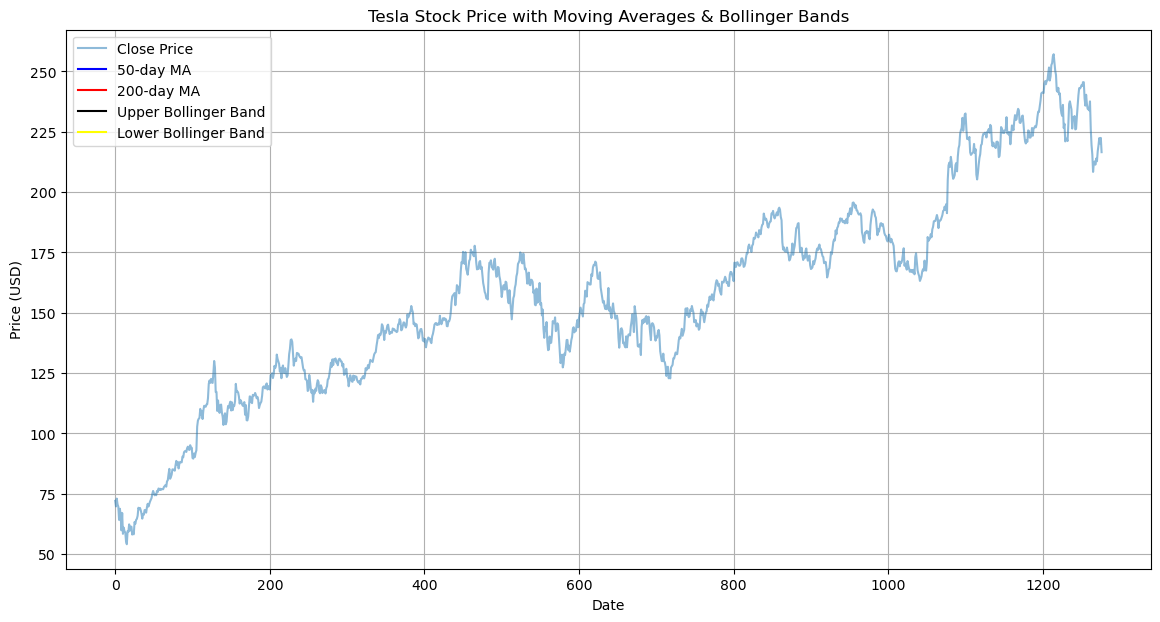

In [15]:
#Plot Closing Price with Moving Averages and Bollinger Bands

plt.figure(figsize=(14, 7))
plt.plot(data_tsla['Close'], label='Close Price', alpha=0.5)
plt.plot(data_tsla['MA50'], label='50-day MA', color='blue')
plt.plot(data_tsla['MA200'], label='200-day MA', color='red')
plt.plot(data_tsla['Upper_Band'], label='Upper Bollinger Band',  color='black')
plt.plot(data_tsla['Lower_Band'], label='Lower Bollinger Band',  color='yellow')
plt.title("Tesla Stock Price with Moving Averages & Bollinger Bands")
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

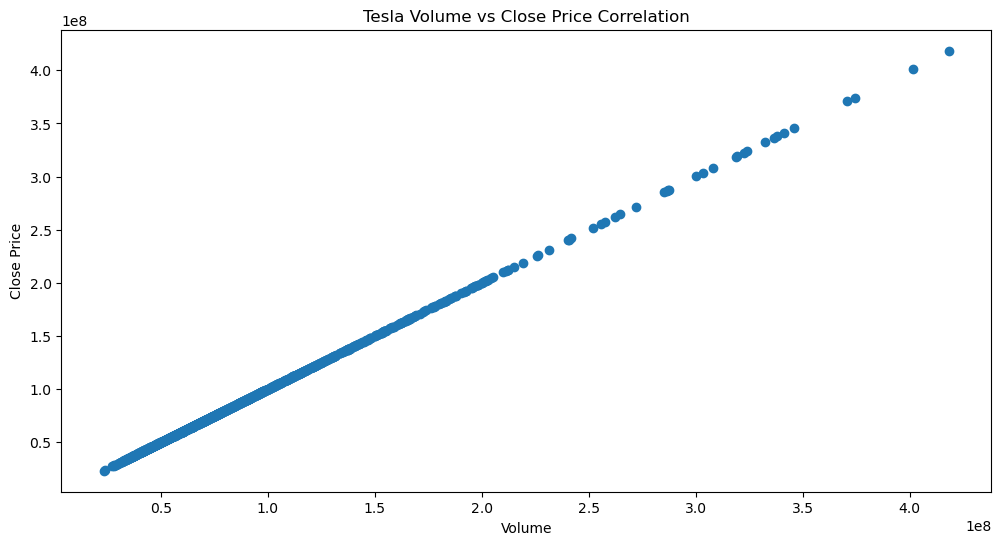

In [16]:
#Volume vs Price Correlation
#sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
plt.scatter(data_tsla['Volume'], (data_tsla['Volume']))
plt.title("Tesla Volume vs Close Price Correlation")
plt.xlabel('Volume')
plt.ylabel('Close Price')
plt.show()

In [17]:
#Volatility analysis
data['Daily_Return'] = data['Close'].pct_change() 
volatility = data['Daily_Return'].rolling(window=30).std() * 100

data['Volatility'] = volatility
high_vol = data['Volatility'].nlargest(5)
print("Highest Volatility Periods:\n", data.loc[high_vol.index][['Volatility']])

Highest Volatility Periods:
 Price  Volatility
Ticker           
0             NaN
1             NaN
2             NaN
3             NaN
4             NaN


In [ ]:
STOCK ANALYSIS FOR MICROSOFT

In [18]:
start_date = '2020-03-01'
end_date = '2025-03-31'

tickers = ("MSFT")
data_msft = yf.download(tickers, start=start_date, end=end_date)
data_msft = data.reset_index()

[*********************100%***********************]  1 of 1 completed


In [59]:
data_msft.head(5)

Price,index,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility
Ticker,,,TSLA,TSLA,TSLA,TSLA,TSLA,,
0,0,2020-03-02,49.574669,49.579334,45.778000,47.417332,302925000,NaN,NaN
1,1,2020-03-03,49.700668,53.798668,47.740665,53.666668,386760000,0.002542,NaN
2,2,2020-03-04,49.966667,51.101334,48.315334,50.930668,225735000,0.005352,NaN
3,3,2020-03-05,48.302666,49.716667,47.871334,48.251331,162790500,-0.033302,NaN
4,4,2020-03-06,46.898666,47.133331,45.618000,46.000000,189943500,-0.029067,NaN


In [19]:
#50 and 200 days moving averages
data_msft['MA50'] = data_msft['Close'].rolling(window=50).mean()
data_msft["MA200"] = data_msft['Close'].rolling(window=200).mean()
data_msft['MA20'] = data_msft['Close'].rolling(window=20).mean()
data_msft['STD20'] = data_msft['Close'].rolling(window=20).std()
data_msft['Upper_Band'] = data_msft['MA20'] + (2 * data_msft['STD20'])
data_msft['Lower_Band'] = data_msft['MA20'] - (2 * data_msft['STD20'])

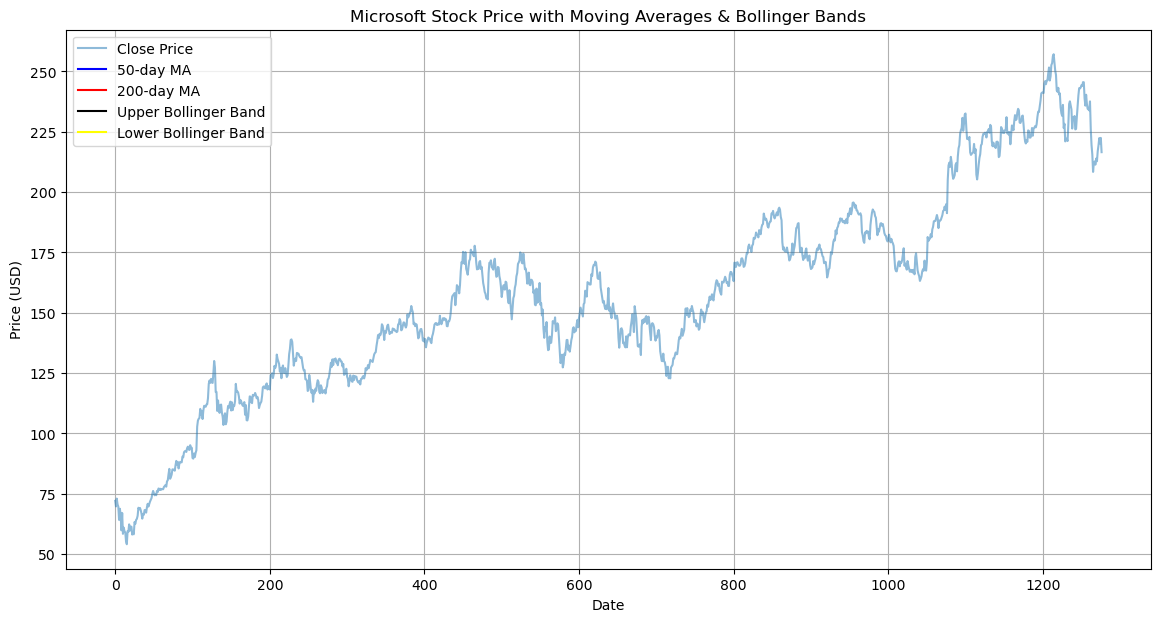

In [20]:
#Plot Closing Price with Moving Averages and Bollinger Bands

plt.figure(figsize=(14, 7))
plt.plot(data_msft['Close'], label='Close Price', alpha=0.5)
plt.plot(data_msft['MA50'], label='50-day MA', color='blue')
plt.plot(data_msft['MA200'], label='200-day MA', color='red')
plt.plot(data_msft['Upper_Band'], label='Upper Bollinger Band',  color='black')
plt.plot(data_msft['Lower_Band'], label='Lower Bollinger Band',  color='yellow')
plt.title("Microsoft Stock Price with Moving Averages & Bollinger Bands")
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

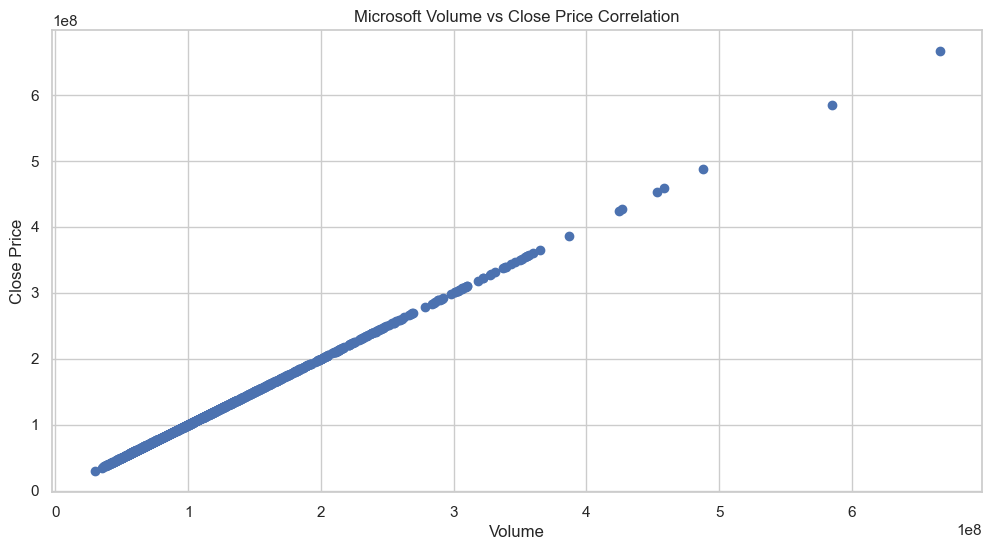

In [63]:
#Volume vs Price Correlation
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
plt.scatter(data_msft['Volume'], (data_msft['Volume']))
plt.title("Microsoft Volume vs Close Price Correlation")
plt.xlabel('Volume')
plt.ylabel('Close Price')
plt.show()

 positive correlation: increase in volume brings increase in price tesla stock

In [64]:
data_msft['Daily_Return'] = data_msft['Close'].pct_change() 
volatility = data_msft['Daily_Return'].rolling(window=30).std() * 100

data_msft['Volatility'] = volatility
high_vol = data['Volatility'].nlargest(5)
print("Highest Volatility Periods:\n", data.loc[high_vol.index][['Volatility']])

Highest Volatility Periods:
 Price  Volatility
Ticker           
32       8.708997
31       8.702800
30       8.689893
33       8.682082
34       8.663219


In [ ]:
GOOGLE STOCK ANALYSIS

In [21]:
start_date = '2020-03-01'
end_date = '2025-03-31'

tickers = ('GOOGL')
data_googl = yf.download( tickers, start = start_date, end = end_date)
data_googl = data.reset_index

[*********************100%***********************]  1 of 1 completed


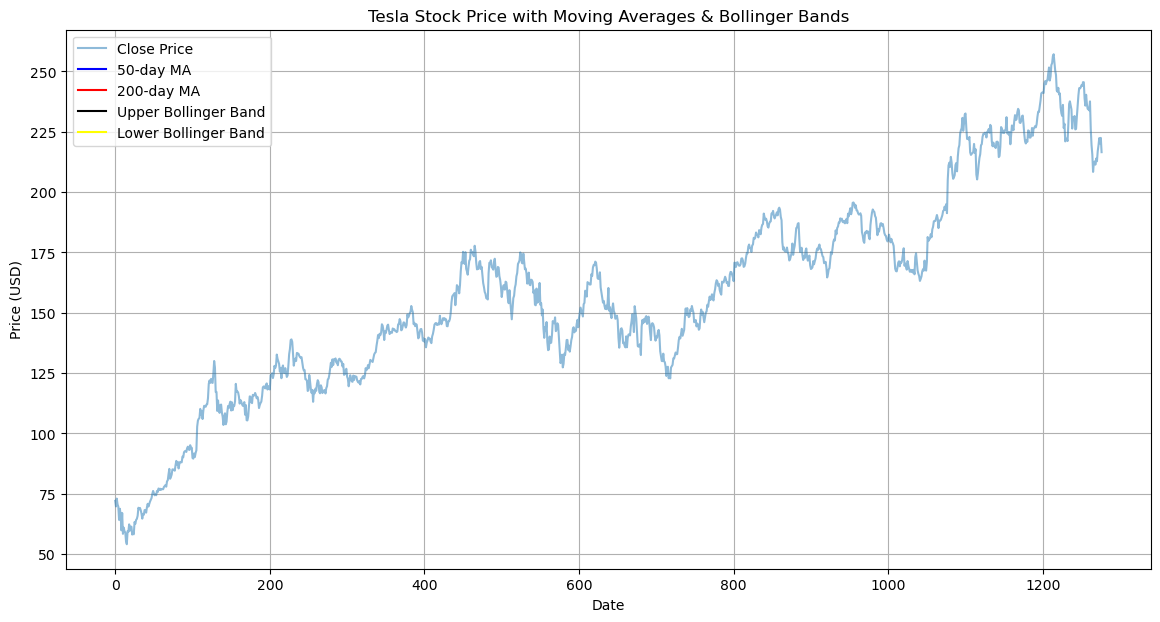

In [22]:
#50 and 200 days moving averages
data_tsla['MA50'] = data_tsla['Close'].rolling(window=50).mean()
data_tsla["MA200"] = data_tsla['Close'].rolling(window=200).mean()
data_tsla['MA20'] = data_tsla['Close'].rolling(window=20).mean()
data_tsla['STD20'] = data_tsla['Close'].rolling(window=20).std()
data_tsla['Upper_Band'] = data_tsla['MA20'] + (2 * data_tsla['STD20'])
data_tsla['Lower_Band'] = data_tsla['MA20'] - (2 * data_tsla['STD20'])

#Plot Closing Price with Moving Averages and Bollinger Bands

plt.figure(figsize=(14, 7))
plt.plot(data_tsla['Close'], label='Close Price', alpha=0.5)
plt.plot(data_tsla['MA50'], label='50-day MA', color='blue')
plt.plot(data_tsla['MA200'], label='200-day MA', color='red')
plt.plot(data_tsla['Upper_Band'], label='Upper Bollinger Band',  color='black')
plt.plot(data_tsla['Lower_Band'], label='Lower Bollinger Band',  color='yellow')
plt.title("Tesla Stock Price with Moving Averages & Bollinger Bands")
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

### Insight

Microsoft stock experienced  downturn in 2020,but  from late 2021 it experienced growth
When the average price over the past few weeks moved higher than the average price over the past several months, it was often a good time to buy.
When the opposite happened, it usually meant the stock might drop and it was a warning to be careful.

Positive correlation: increase in volume brings increase in price tesla stock
Positive correlation: increase in volume brings increase in price apple stock
Short-term moving averages crossing above long-term ones signaled strong buying opportunities in Apple Stock
TSLA stock experienced growth from late 2020 to early 2022.
When the average price over the past few weeks moved higher than the average price over the past several months, it was often a good time to buy.
When the opposite happened, it usually meant the stock might drop, and it was a warning to be careful.